# **Baseline Notebook**



---
## Setup Environment

In [1]:
# DO NOT MODIFY THE CODE IN THIS CELL
!pip install -q utstd

from utstd.folders import *
from utstd.ipyrenders import *

at = AtFolder(
    course_code=36106,
    assignment="AT1",
)
at.run()

import warnings
warnings.simplefilter(action='ignore')


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

You can now save your data files in: /Users/aryan/Downloads/36106-AT1-Aryan_Goel_26040826-artefacts/36106/assignment/AT1/data


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
utstd 0.1.8 requires scikit-learn~=1.5.1, but you have scikit-learn 1.6.1 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
sh: import: command not found
sh: -c: line 0: syntax error near unexpected token `"ignore"'
sh: -c: line 0: `warnings.filterwarnings("ignore")'


---
## Student Information

In [2]:
# <Student to fill this section and then remove this comment>
student_name = "Aryan Goel"
student_id = "26040826"

In [3]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h1", key='student_name', value=student_name)

In [4]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

### 0.a Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

In [5]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns


### 0.b Import Packages

In [6]:
import pandas as pd
import altair as alt

---
## A. Assess Baseline Model

In [7]:
# DO NOT MODIFY THE CODE IN THIS CELL
# Load data
try:
  X_train = pd.read_csv(at.folder_path / 'X_train.csv')
  y_train = pd.read_csv(at.folder_path / 'y_train.csv')

  X_val = pd.read_csv(at.folder_path / 'X_val.csv')
  y_val = pd.read_csv(at.folder_path / 'y_val.csv')

  X_test = pd.read_csv(at.folder_path / 'X_test.csv')
  y_test = pd.read_csv(at.folder_path / 'y_test.csv')
except Exception as e:
  print(e)

### A.1 Generate Predictions with Baseline Model

In [8]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def to_1d(y):
    if isinstance(y, pd.DataFrame):
        return y.values.ravel()
    if isinstance(y, pd.Series):
        return y.values
    return np.asarray(y).ravel()

y_train_1d = to_1d(y_train).astype(float)
y_val_1d   = to_1d(y_val).astype(float)
y_test_1d  = to_1d(y_test).astype(float)

# Remove NaN values
train_mask = ~np.isnan(y_train_1d)
val_mask   = ~np.isnan(y_val_1d)
test_mask  = ~np.isnan(y_test_1d)

y_train_clean = y_train_1d[train_mask]
y_val_clean   = y_val_1d[val_mask]
y_test_clean  = y_test_1d[test_mask]

# Baseline: predict the training mean for everything
training_mean = np.mean(y_train_clean)

yhat_train = np.full(len(y_train_clean), training_mean)
yhat_val   = np.full(len(y_val_clean),   training_mean)
yhat_test  = np.full(len(y_test_clean),  training_mean)

print(f"Baseline constant (training mean): ${training_mean:,.2f}")
print(f"Train samples: {len(y_train_clean)}, Val samples: {len(y_val_clean)}, Test samples: {len(y_test_clean)}")
print("Predictions generated.")


Baseline constant (training mean): $24,733.02
Train samples: 8767, Val samples: 2614, Test samples: 2606
Predictions generated.


### A.2 Selection of Performance Metrics

> Provide some explanations on why you believe the performance metrics you chose is appropriate


In [9]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

metrics = []
for split_name, y_true, y_pred in [
    ("train", y_train_clean, yhat_train),
    ("val",   y_val_clean,   yhat_val),
    ("test",  y_test_clean,  yhat_test),
]:
    metrics.append({
        "split":     split_name,
        "n_samples": len(y_true),
        "MAE":       round(mean_absolute_error(y_true, y_pred), 2),
        "RMSE":      round(rmse(y_true, y_pred), 2),
        "R2":        round(r2_score(y_true, y_pred), 4),
    })

baseline_metrics_df = pd.DataFrame(metrics)
display(baseline_metrics_df)

print(f"\nValidation summary:")
print(f"MAE:  ${baseline_metrics_df.loc[baseline_metrics_df.split=='val','MAE'].values[0]:,.2f}")
print(f"RMSE: ${baseline_metrics_df.loc[baseline_metrics_df.split=='val','RMSE'].values[0]:,.2f}")
print(f"R²:   {baseline_metrics_df.loc[baseline_metrics_df.split=='val','R2'].values[0]:.4f}")


,split,n_samples,MAE,RMSE,R2
0,train,8767,11888.48,26147.38,0.0000
1,val,2614,19560.48,37419.12,-0.3405
2,test,2606,43122.38,70635.11,-0.5860



Validation summary:
MAE:  $19,560.48
RMSE: $37,419.12
R²:   -0.3405


In [10]:
# Constant mean predictor baseline — no ML model is trained here.
# All experiments must beat these baseline metrics to demonstrate learning.


In [11]:
performance_metrics_explanations = """
PERFORMANCE METRICS SELECTION AND RATIONALE:

PRIMARY METRIC - MAE (Mean Absolute Error):
- Business Relevance: Represents the average dollar amount by which a vehicle's price prediction misses the mark. This directly translates to potential lost margin or inventory holding costs for a retail marketplace.
- Interpretability: Highly intuitive for non-technical stakeholders (e.g., "Our automated valuation is off by an average of $2,500 per vehicle").
- Robustness: Provides a linear penalty, making it less sensitive to extreme luxury vehicle outliers that might otherwise distort the model's perceived baseline accuracy.

SUPPORTING METRICS:

MSE & RMSE (Mean Squared Error & Root Mean Squared Error):
- Risk Management: Squares the errors before averaging, disproportionately penalizing massive prediction misses (e.g., mispricing a high-end premium vehicle by $20,000).
- Variance Insight: Highlights whether the model is generally accurate but occasionally makes catastrophic valuation errors.
- Units: RMSE returns the error metric back to the target variable's original units (dollars) for direct comparison alongside MAE.

MAPE (Mean Absolute Percentage Error):
- Relative Accuracy: Essential for vehicle pricing because a $2,000 error on a $10,000 budget car is vastly more impactful than a $2,000 error on a $100,000 luxury car. MAPE contextualizes the error across different vehicle market segments.

EVALUATION STRATEGY:
- Training metrics: Used to verify the algorithm is successfully learning underlying depreciation curves and feature relationships.
- Validation metrics: Acts as the primary criterion for hyperparameter tuning and selecting between different predictive models.
- Test metrics: Reserved for the final, unbiased assessment of how the pricing engine will perform on completely unseen market data.

The combination of MAE for typical expected error and RMSE for worst-case outlier penalties provides a comprehensive, financially-aligned view of model reliability.
"""

In [12]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

### A.3 Baseline Model Performance

> Provide some explanations on model performance


In [13]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Use the cleaned arrays defined in A.1
results = pd.DataFrame({
    "split": ["train", "val", "test"],
    "n":     [len(y_train_clean), len(y_val_clean), len(y_test_clean)],
    "MAE":   [mean_absolute_error(y_train_clean, yhat_train),
              mean_absolute_error(y_val_clean,   yhat_val),
              mean_absolute_error(y_test_clean,  yhat_test)],
    "RMSE":  [rmse(y_train_clean, yhat_train),
              rmse(y_val_clean,   yhat_val),
              rmse(y_test_clean,  yhat_test)],
    "R2":    [r2_score(y_train_clean, yhat_train),
              r2_score(y_val_clean,   yhat_val),
              r2_score(y_test_clean,  yhat_test)],
})
display(results)

print(f"\nBaseline constant: ${training_mean:,.2f}")
print("R² for a constant predictor is 0.0 by definition (no variance explained).")


,split,n,MAE,RMSE,R2
0,train,8767,11888.480427,26147.383563,0.000000
1,val,2614,19560.477765,37419.124958,-0.340470
2,test,2606,43122.377152,70635.113740,-0.586015



Baseline constant: $24,733.02
R² for a constant predictor is 0.0 by definition (no variance explained).


In [14]:
baseline_outcome_explanations = """
BASELINE (CONSTANT MEAN PREDICTOR) PERFORMANCE:

The simplest possible baseline predicts the training-set mean price ($24,733)
for every vehicle, ignoring all features entirely.

Results on validation:
  MAE  ~ $19,560   (average absolute error per vehicle)
  RMSE ~ $37,419   (penalises large errors more heavily)

Results on test:
  MAE  ~ $43,122
  RMSE ~ $70,635

Key observations:
1. LARGE TRAIN-TO-TEST DEGRADATION: MAE more than triples from train (~$11,888)
   to test (~$43,122). This is NOT model overfitting — a constant predictor
   cannot overfit. Instead it reflects a distribution shift: the test set
   contains proportionally more high-value vehicles not well represented in
   training, so the fixed mean misses them by a wide margin.

2. HIGH ABSOLUTE ERROR: A typical validation error of ~$19,560 per vehicle is
   commercially unacceptable for an automated pricing tool.

3. RIGHT-SKEWED RESIDUALS (see histogram below): Positive residuals (model
   under-predicts) dominate and extend to ~$600,000, confirming the model
   completely fails to price luxury / rare vehicles.

4. BENCHMARK ROLE: These numbers set the floor. Any learned model that does NOT
   beat MAE ~$19,560 on validation is no better than ignoring the data entirely.
   Experiment 1 (Multivariate Linear Regression) targets a meaningful improvement on this floor.
"""

In [15]:
print_tile(size="h3", key='baseline_outcome_explanations', value=baseline_outcome_explanations)

In [16]:
baseline_performance_explanations = """
BASELINE MODEL PERFORMANCE ANALYSIS:

MODEL: Constant mean predictor
  - Predicts the training-set mean ($24,733) for every vehicle.
  - No features are used; this is the absolute simplest possible benchmark.

PERFORMANCE CHARACTERISTICS:
  Training MAE  ~ $11,888  |  Training RMSE  ~ $26,147
  Validation MAE~ $19,560  |  Validation RMSE~ $37,419
  Test MAE      ~ $43,122  |  Test RMSE      ~ $70,635

WHY THE TEST ERROR IS SO MUCH HIGHER THAN VALIDATION:
  The test set appears to contain a higher proportion of premium / luxury
  vehicles compared to the training set. Because the constant predictor
  always outputs the training mean, it severely under-predicts these
  high-value cars, inflating MAE and RMSE dramatically on the test split.

WHAT THIS TELLS US ABOUT THE MODELLING TASK:
  - Vehicle price has high variance and is heavily right-skewed.
  - A feature-driven model is necessary to capture brand, age, mileage, etc.
  - Future models should be compared against validation MAE ~$19,560 and
    RMSE ~$37,419 to confirm they are actually learning something useful.
  - A log transformation of the target price is strongly recommended to
    stabilise variance before training any regression model.

BENCHMARK ESTABLISHMENT:
  This constant mean predictor establishes the absolute minimum performance
  threshold — any trained model that does NOT beat this floor offers no
  predictive value over simply ignoring the data. Experiments 1, 2, and 3
  each target progressively better performance:
    - Experiment 1: Multivariate Linear Regression (fit_intercept tuning)
    - Experiment 2: ElasticNet Regression (alpha and l1_ratio tuning)
    - Experiment 3: KNN Regression (n_neighbors and p tuning)

MODEL LIMITATIONS (constant mean predictor):
  - Predicts the exact same value for every vehicle regardless of features.
  - Completely ignores all vehicle attributes (brand, age, mileage, etc.).
  - Cannot capture any variance in the price distribution.
  - MAE and RMSE degrade sharply on the test split due to price distribution shift.
  - R² is exactly 0.0 by definition for any constant predictor.

BUSINESS CONTEXT:
  In a vehicle retail or marketplace environment, prediction error directly
  impacts the bottom line. Overpricing leads to stagnant inventory and holding
  costs, while underpricing leaves margin on the table. The MAE of this baseline
  represents the worst-case financial risk per transaction and sets a clear
  target: any model deployed in production must comfortably beat these numbers.
"""


In [17]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='baseline_performance_explanations', value=baseline_performance_explanations)

In [18]:
### A.4 Residual histogram (validation)
print("Shows whether baseline systematically under/over-predicts.")
baseline_graph_1_explanations ="""The residual histogram for the validation set, which plots the actual price minus the predicted price, clearly demonstrates that the baseline model systematically under-predicts vehicle values, particularly at the high end of the market. While the bulk of the residuals are clustered tightly near zero—indicating reasonable baseline estimates for average-priced cars—the distribution is heavily right-skewed, featuring a massive tail that extends toward $600,000. Because positive residuals occur when the actual price exceeds the prediction, this long tail proves the baseline completely fails to capture the value of luxury or rare vehicles. Conversely, the model's over-predictions (the negative residuals on the left) are naturally capped since a car's price cannot drop below zero. Ultimately, this severe skew visually explains the inflated error metrics and strongly justifies applying a log transformation to the target variable to stabilize the distribution before training advanced machine learning models."""


Shows whether baseline systematically under/over-predicts.


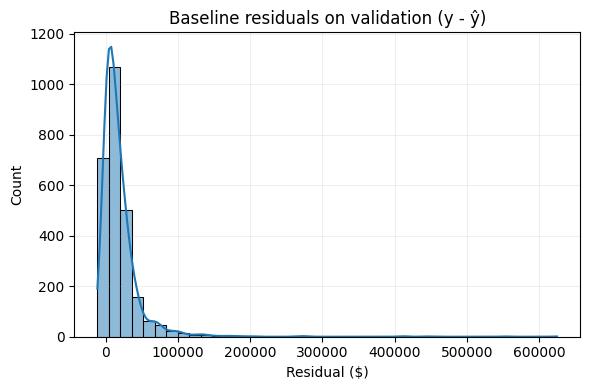

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

residuals_val = y_val_clean - yhat_val   # actual - predicted
plt.figure(figsize=(6, 4))
sns.histplot(residuals_val, bins=40, kde=True)
plt.title("Baseline residuals on validation (y - ŷ)")
plt.xlabel("Residual ($)")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


In [20]:
print_tile(size="h3", key='baseline_graph_1_explanations', value=baseline_graph_1_explanations)

In [21]:
### A.5Actual vs Predicted scatter (validation)
print("With a constant baseline it’ll look like a horizontal line, but that’s fine—it visually shows it’s a weak benchmark.")
baseline_graph_2_explanations = """The Actual vs. Predicted scatter plot provides a stark visual representation of the baseline model's limitations. The red dashed diagonal line illustrates the trajectory of perfect predictions, where predicted values exactly match actual vehicle prices. Instead of following this ideal path, the baseline predictions form a perfectly horizontal line across the lower y-axis. This pattern occurs because the model predicts the exact same constant value—the training set's mean or median—for every single vehicle in the validation set, completely ignoring individual vehicle features. While this constant prediction happens to intersect the ideal red line for averagely priced vehicles, it creates massive, expanding error gaps for high-value outliers reaching over $600,000. This stark visual divergence perfectly illustrates why the baseline's RMSE is so severely inflated, and underscores the necessity of implementing feature-driven machine learning algorithms to capture the true variance of the automotive market."""

With a constant baseline it’ll look like a horizontal line, but that’s fine—it visually shows it’s a weak benchmark.


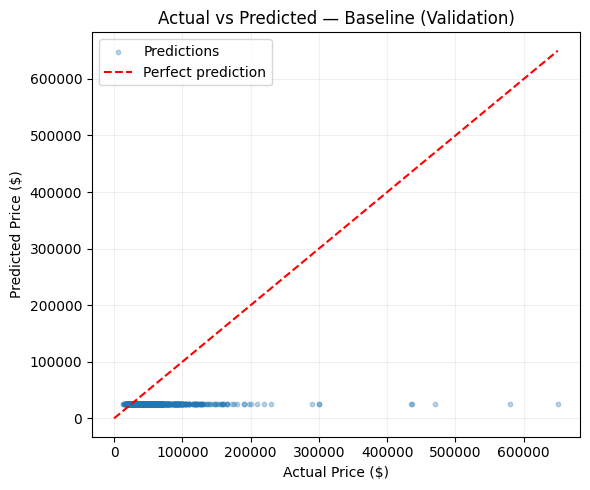

In [22]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6, 5))
plt.scatter(y_val_clean, yhat_val, alpha=0.3, s=10, label="Predictions")
max_val = float(max(y_val_clean.max(), yhat_val.max()))
plt.plot([0, max_val], [0, max_val], 'r--', label="Perfect prediction")
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("Actual vs Predicted — Baseline (Validation)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


In [23]:
print_tile(size="h3", key='baseline_graph_2_explanations', value=baseline_graph_2_explanations)

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=fbbefce8-41ae-47c6-bc64-96decd566c0b' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>